In [2]:
#@title Importar librerías
#importar librerías necesarias
import os
import logging
import time

import numpy as np
import matplotlib.pyplot as plt

import tensorflow_datasets as tfds
import tensorflow as tf

import tensorflow_text

import warnings
warnings.filterwarnings('ignore')

In [3]:
#@title Funciones complementarias
def plot_similaridad_positional_encodings(pos_encoding):
  # normalización de los vectores a 1
  pos_encoding/=tf.norm(pos_encoding, axis=1, keepdims=True)
  # seleccionamos el vector de la posición 1000
  p = pos_encoding[1000]
  # cálculo de la similitud del producto punto
  dots = tf.einsum('pd,d -> p', pos_encoding, p)

  # visualización de la relación de los vectores con sus palabras
  # vecinas, por definición tendran mucha similaridad.
  plt.subplot(2,1,1)
  plt.plot(dots)
  plt.ylim([0,1])
  plt.plot([950, 950, float('nan'), 1050, 1050],
          [0,1,float('nan'),0,1], color='k', label='Zoom')
  plt.legend()
  plt.subplot(2,1,2)
  plt.plot(dots)
  plt.xlim([950, 1050])
  plt.ylim([0,1])

def plot_distribucion_longitudes_tokens(all_lengths):
  plt.hist(all_lengths, np.linspace(0, 500, 101))
  plt.ylim(plt.ylim())
  max_length = max(all_lengths)
  plt.plot([max_length, max_length], plt.ylim())
  plt.title(f'Número máximo de tokens por muestra: {max_length}');

def plot_positional_encodings(pos_encoding):
  # Gráficar las dimensiones
  plt.pcolormesh(pos_encoding.numpy().T, cmap='RdBu')
  plt.ylabel('Profundidad')
  plt.xlabel('Posición')
  plt.colorbar()
  plt.show()

def plot_lr_planificador(learning_rate):
  plt.plot(learning_rate(tf.range(40000, dtype=tf.float32)))
  plt.ylabel('Learning Rate');
  plt.xlabel('Paso de entrenamiento');

def plot_attention_head(in_tokens, translated_tokens, attention):
  # Saltar el token start.
  translated_tokens = translated_tokens[1:]

  ax = plt.gca()
  ax.matshow(attention)
  ax.set_xticks(range(len(in_tokens)))
  ax.set_yticks(range(len(translated_tokens)))

  labels = [label.decode('utf-8') for label in in_tokens.numpy()]
  ax.set_xticklabels(
      labels, rotation=90)

  labels = [label.decode('utf-8') for label in translated_tokens.numpy()]
  ax.set_yticklabels(labels)

def plot_attention_weights(sentence, translated_tokens, attention_heads):
  in_tokens = tf.convert_to_tensor([sentence])
  in_tokens = tokenizers.pt.tokenize(in_tokens).to_tensor()
  in_tokens = tokenizers.pt.lookup(in_tokens)[0]

  fig = plt.figure(figsize=(12, 15))

  for h, head in enumerate(attention_heads):
    ax = fig.add_subplot(2, 4, h+1)

    plot_attention_head(in_tokens, translated_tokens, head)

    ax.set_xlabel(f'Head {h+1}')

  plt.tight_layout()
  plt.show()

def plot_traduccion(sentence, tokens, ground_truth):
  print(f'{"Input:":15s}: {sentence}')
  print(f'{"Predicción":15s}: {tokens.numpy().decode("utf-8")}')
  print(f'{"Ground truth":15s}: {ground_truth}')

<center><h1>Transformers</center>

<b>Maestría</b>: Inteligencia Artificial Aplicada <br>
<b>Asignatura:</b> Procesamiento Acelerado de Lenguaje Natural <br>
<b>Profesor:</b> Edwin J. Rueda

## ¿Qué son los Transformers?

Los Transformers, propuestos en el artículo ["Attention is all you need"](https://arxiv.org/abs/1706.03762), han revolucionado el campo de NLP, ofreciendo ventajas significativas sobre las RNNs. **Los Transformers son redes neuronales profundas que reemplazan las CNNs y las RNNs. Estos introducen la auto-atención (self-attention), que permite a los Transformers transmitir información fácilmente a través de las secuencias de entrada.**

**¿Por qué los Transformers son importantes?**

* **Paralelización:** A diferencia de las RNNs, los Transformers pueden procesar todos los elementos de una secuencia en paralelo, lo que permite un entrenamiento mucho más rápido en hardware moderno como GPUs y TPUs.
* **Captura de dependencias temporales de larga duración:** Los Transformers utilizan mecanismos de atención que permiten a cada posición de la secuencia prestar atención a todas las demás posiciones, facilitando el aprendizaje de relaciones entre elementos distantes. Las RNNs tienen dificultades para esto debido a la necesidad de procesar la secuencia paso a paso.

### Componentes principales:
- **Positional Encoding**: agrega información del orden de las palabras.
- **Self-Attention**: permite al modelo enfocarse en diferentes partes del texto de entrada.
- **Capa de atención múltiple (Multi-head)**: combina varias atenciones para capturar distintos patrones.
- **Bloques de codificador y decodificador**.

Transformers son la base de modelos como BERT, GPT, T5, etc.


### ¿Cómo funcionan los Transformers?

Una de las funciones principales de un *transformer* es la traducción. Para ello, partamos desde un ejemplo base:

- Entrada: Frase en el idioma orignal -> eu sou estudante
- Salida: Frase traducida -> I am a student

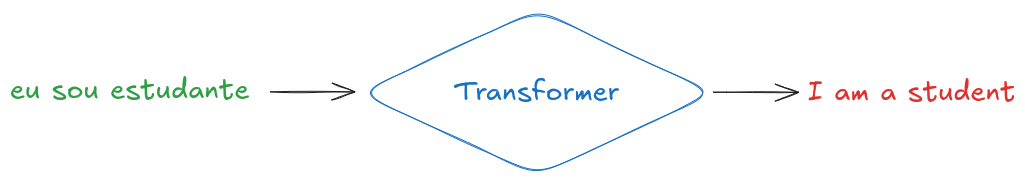

si desglosamos el `transformer` tenemos dos componentes: el `codificador` y el `decodificador`

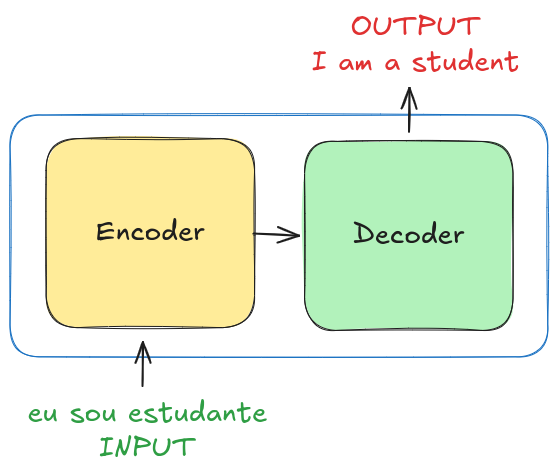

Este tipo de tarea de predicción de la siguiente palabra dadas $n$ palabras previas es llamada [*causal language modeling*](https://huggingface.co/docs/transformers/tasks/language_modeling):

<center>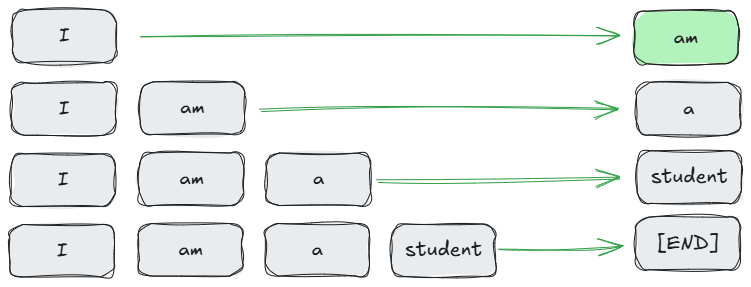</center>

Cada `Encoder` y `Decoder` son componentes que cuentan con varios codificadores y decodificadores apilados, esta cantidad es seleccionada después de un ajuste de hiperparámetros:

- ***Encoder***: Se encarga de dada una entrada, construir una representación de esta (entender la relación de su entrada: orden de palabras, relaciones entre las palabras, etc).
- ***Decoder***: En base a la representación generada por el *Encoder*, y su propia entrada, genera una secuencia objetivo. (se optimiza para generar una salida).

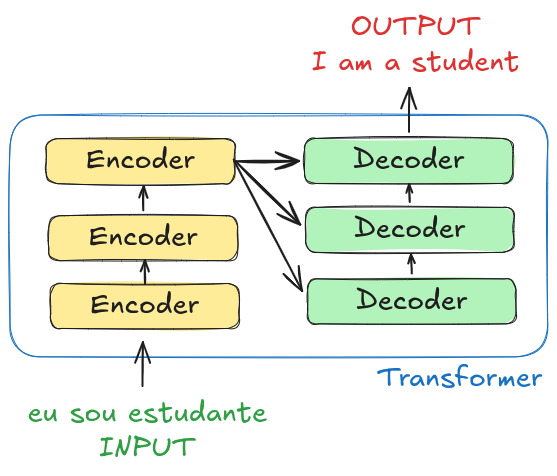

cada `Encoder` cuenta con dos submódulos principales: `self-attention`, `FFNN (Feed Forward Neural Network)`

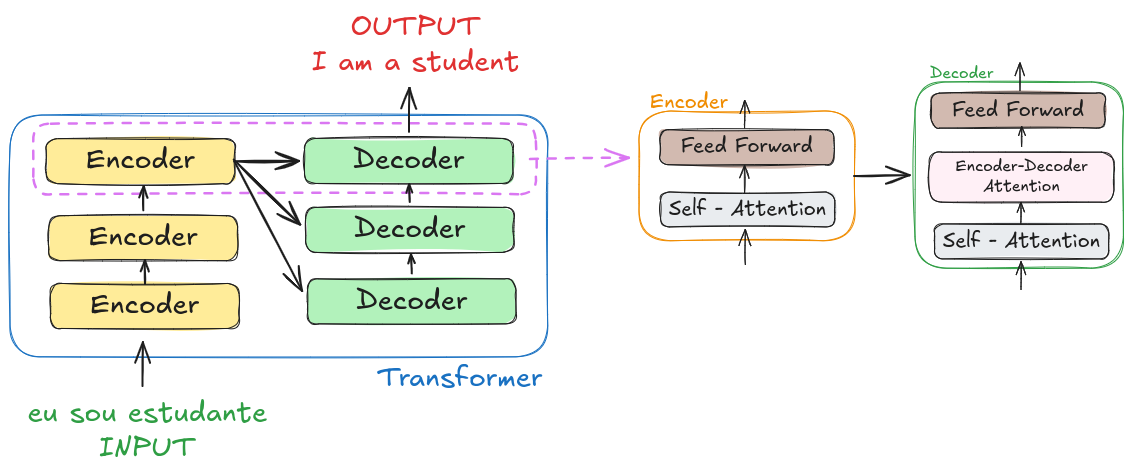

Uno de los principales beneficios de este tipo de arquitectura, es que si tenemos una entrada `eu sou estudante`, cada palabra se codifica en un vector `embedding` que entra de forma simultanea a la capa de `self-attention`, pero esta salida, se puede pasar en paralelo (cada `embedding`) a la capa de `Feed Forward`.

Note que cada una de las partes del *Transformer* puede ser utilizada para una tarea en específico:
- *Encoder*: Debido a que captura relaciones entre la entrada, es útil para tareas de clasificicación. (BERT)
- *Decoder*: Nos sirve para tareas de generación de texto. (GPT)
- *Encoder-Decoder*: Tareas de generación en base a un contexto de entrada, como la traducción. (T5)

### ¿Que función tiene la capa de `self-attention` ?

Esta capa permite relacionar cada palabra de nuestra sentencia de entrada con las demás palabras, permitiendo relacionar o darle mayor "atención" a determinadas palabras. Por ejemplo, dada la oración:

- "El perro que estaba en el jardín corrió y se fue"

a simple vista, nosotros podemos deducir que la palabra "corrió" hace referencia al perro. Pero los modelos no pueden intuirlo. Por lo cual, la capa de `self-attention` se encarga de relacionar estas palabras (como lo veremos mas adelante).


<center>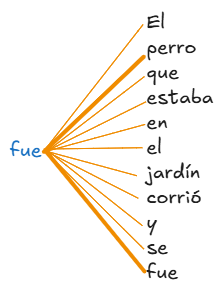</center>

### ¿Que es una `Feed Forward Neural Network` ?

Este tipo de redes neuronales, son redes las cuales la información fluye de inicio a fin (en un único sentido), no existen ciclos y están compuestas de la siguiente manera:

- Capa de entrada
- Capa(s) oculta(s)
- Capa de salida

La intuición es sencilla, dada una entrada $x$, se procesa por las capas $f(x)$, obteniendo una salida $y$

$$ f(x) \text{->} y $$

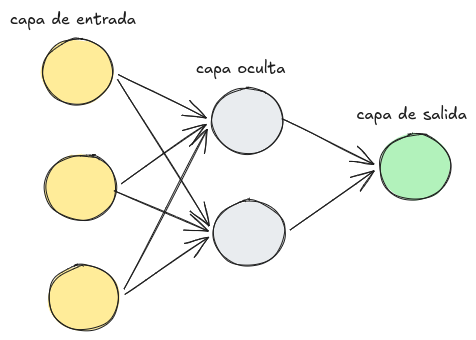

A parte de estos componentes principales, el `Transformer` hace uso de `Positional Embeddings` y capas de normalización que abordaremos mas adelante

## ¿Cómo construir un transformer?

Ya abordamos de forma general los componentes principales de un transformer. Con lo anterior en mente, el siguiente paso es contruirlo. Para ellos, abordaremos los siguientes pasos:

1.  Preparar los datos de entrenamiento y validación
2.  Implementar los componentes necesarios para un transformer
    * Embeddings posicionales.
    * Capas de atención.
    * Feed Forward Neural Networks.
    * El codificador y el decodificador.
3.  Entrenar el Transformer.
4.  Generar traducciones.
5.  Exportar el modelo.

#### 1. Carga y preprocesamiento de los datos

Para esta práctica, utilizaremos un conjunto de datos de traducción Portugués-Inglés, y utilizaremos un tokenizador para preparar el texto para nuestro modelo. Este conjunto de datos se distribuye de la siguiente forma:

- 5116 ejemplos de entrenamiento
- 640 de validación
- 640 de prueba


In [1]:
from datasets import load_dataset

ds = load_dataset("Lots-of-LoRAs/task1274_ted_translation_pt_en")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.78k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.35M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/172k [00:00<?, ?B/s]

data/valid-00000-of-00001.parquet:   0%|          | 0.00/170k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating valid split: 0 examples [00:00, ? examples/s]

In [5]:
train_examples, val_examples = ds['train'], ds['valid']

In [6]:
ds['train'], ds['valid'], ds["test"]

(Dataset({
     features: ['input', 'output', 'id'],
     num_rows: 5116
 }),
 Dataset({
     features: ['input', 'output', 'id'],
     num_rows: 640
 }),
 Dataset({
     features: ['input', 'output', 'id'],
     num_rows: 640
 }))

In [7]:
ds["train"][0]

{'input': "Definition: You are given a sentence in Portuguese. Your job is to translate the Portuguese sentence into English.\n\nPositive Example 1 -\nInput: Os astrónomos acreditam que cada estrela da galáxia tem um planeta, e especulam que até um quinto deles tem um planeta do tipo da Terra que poderá ter vida, mas ainda não vimos nenhum deles.\nOutput: Astronomers now believe that every star in the galaxy has a planet, and they speculate that up to one fifth of them have an Earth-like planet that might be able to harbor life, but we haven't seen any of them.\n\nPositive Example 2 -\nInput: O problema é que nunca vivi lá um único dia.\nOutput: Except, I've never lived one day of my life there.\n\nNegative Example 1 -\nInput: Agora: um, dois, três, vai.\nOutput: So: one, two, four, go.\n\nNegative Example 2 -\nInput: Eventualmente, vamos ver se teremos todos os sentidos humanos empregues, e se vamos ter meios para viver a história qualquer que seja a via escolhida.\nOutput: Eventually

Convertimos el formato a Tensores para poder entrenar nuestro Transformer

In [8]:
import re
import tensorflow as tf

def hf_to_tf(dataset_split):

    def generator():
        for example in dataset_split:
            # Capturar el texto después de "Input:"
            match = re.search(
                r"Now complete the following example -\nInput:\s*(.*?)\nOutput:",
                example['input'],
                re.DOTALL
            )

            if match:
                source_text = match.group(1).strip()

                # output es una lista -> tomar el primer elemento
                target_text = example['output'][0].strip()

                yield (source_text, target_text)

    return tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(), dtype=tf.string),
            tf.TensorSpec(shape=(), dtype=tf.string)
        )
    )

train_examples = hf_to_tf(ds["train"])
test_examples = hf_to_tf(ds["test"])
val_examples = hf_to_tf(ds["valid"])

Aquí nos devuelve un iterador de tuplas (pt, en)

In [9]:
# Mostrar algunos ejemplos de parejas de oraciones
for pt_examples, en_examples in train_examples.batch(1).take(1):
  print('-> Ejemplos en portugués:')
  for pt in pt_examples.numpy():
    print(pt.decode('utf-8'))
  print()

  print('-> Traducción al inglés:')
  for en in en_examples.numpy():
    print(en.decode('utf-8'))

-> Ejemplos en portugués:
Se observarmos a biologia, provavelmente muitos de vocês não sabem, mas eu estudava biologia antes de seguir para a a arquitetura, a pele humana é o órgão que regula naturalmente a temperatura do corpo, o que é algo fantástico.

-> Traducción al inglés:
If we look at biology, and many of you probably don't know, I was a biology major before I went into architecture, the human skin is the organ that naturally regulates the temperature in the body, and it's a fantastic thing.


#### Tokenizador

En nuestro ejemplo vamos a usar los tokenizadores construidos en el tutorial [subword tokenizer](https://www.tensorflow.org/text/guide/subwords_tokenizer). Ese tutorial optimiza dos objetos `text.BertTokenizer` (uno para inglés, otro para portugués) para **un conjunto de datos de traducción** y los exporta en formato `saved_model` de TensorFlow.

Este tokenizador es basado en subpalabras,  lo que permite dividir una plabra/token en fragmentos mas pequeños (*subwords*), en lugar de trabajar con palabras completas:

$$ \text{Internalización} -> \text{intern, ##acion, ##alización}$$

así logramos reducir nuestro vocabulario e inclusive entender palabras no vistas, ya que pueden estar compuestas de fragmentos.

In [10]:
model_name = 'ted_hrlr_translate_pt_en_converter'
tf.keras.utils.get_file(
    f'{model_name}.zip',
    f'https://storage.googleapis.com/download.tensorflow.org/models/{model_name}.zip',
    cache_dir='.', cache_subdir='', extract=True
)

'./ted_hrlr_translate_pt_en_converter_extracted'

In [11]:
# cargar los tokenizadores
tokenizers = tf.saved_model.load(f'{model_name}_extracted/{model_name}')

In [12]:
# ambos tokenizadores tienen los mismo métodos
[item for item in dir(tokenizers.en) if not item.startswith('_')]

['detokenize',
 'get_reserved_tokens',
 'get_vocab_path',
 'get_vocab_size',
 'lookup',
 'tokenize',
 'tokenizer',
 'vocab']

In [13]:
# por ejemplo revisemos los vocab
tokenizers.en.vocab.shape, tokenizers.pt.vocab.shape

(TensorShape([7010]), TensorShape([7765]))

El método `tokenize` convierte un grupo de oraciones en un grupo de identificadores de tokens de una misma longitud (padding). Este método separa los signos de puntuación, las minúsculas y normaliza el texto de entrada antes de la tokenización. Esta normalización no es visible aquí porque los datos de entrada ya están normalizados.

In [14]:
print('-> Esto es un grupo de cadenas:')
for en in en_examples.numpy():
  print(en.decode('utf-8'))

-> Esto es un grupo de cadenas:
If we look at biology, and many of you probably don't know, I was a biology major before I went into architecture, the human skin is the organ that naturally regulates the temperature in the body, and it's a fantastic thing.


In [15]:
encoded = tokenizers.en.tokenize(en_examples)
print(f"Tamaño de la cadena de entrada {len(en_examples.numpy()[0])}")
print(f'-> Este es el grupo de cadena de ID de tokens (con padding): longitud {encoded.row_lengths()[0]}')
for row in encoded.to_list():
  print(row)

Tamaño de la cadena de entrada 224
-> Este es el grupo de cadena de ID de tokens (con padding): longitud 56
[2, 107, 78, 176, 102, 1137, 13, 72, 180, 74, 79, 413, 91, 269, 9, 56, 132, 13, 45, 84, 37, 1137, 935, 244, 45, 252, 156, 1145, 13, 71, 226, 1299, 80, 71, 2464, 75, 2397, 105, 651, 1970, 88, 71, 1692, 77, 71, 366, 13, 72, 76, 9, 55, 37, 1781, 194, 15, 3]


El método `detokenize` convierte los ID de token de nuevo en texto legible normal:

In [16]:
round_trip = tokenizers.en.detokenize(encoded)

print('-> Correspondiente texto:')
for line in round_trip.numpy():
  print(line.decode('utf-8'))

-> Correspondiente texto:
if we look at biology , and many of you probably don ' t know , i was a biology major before i went into architecture , the human skin is the organ that naturally regulates the temperature in the body , and it ' s a fantastic thing .


El método `lookup` convierte de token-IDs a token-texto:

In [17]:
print('-> Este es el texto dividido en tokens:')
tokens = tokenizers.en.lookup(encoded)
tokens

-> Este es el texto dividido en tokens:


<tf.RaggedTensor [[b'[START]', b'if', b'we', b'look', b'at', b'biology', b',', b'and',
  b'many', b'of', b'you', b'probably', b'do', b'##n', b"'", b't', b'know',
  b',', b'i', b'was', b'a', b'biology', b'major', b'before', b'i',
  b'went', b'into', b'architecture', b',', b'the', b'human', b'skin',
  b'is', b'the', b'organ', b'that', b'naturally', b're', b'##g',
  b'##ulate', b'##s', b'the', b'temperature', b'in', b'the', b'body',
  b',', b'and', b'it', b"'", b's', b'a', b'fantastic', b'thing', b'.',
  b'[END]']]>

Ten encuenta que el tokenizador que estamos utilizando, puede descomponer palabras.

Por ejemplo, la palabra `'searchability'` se descompone en `'search'` y `'##ability'`, y la palabra `'serendipity'` en `'s'`, `'##ere'`, `'##nd'`, `'##ip'` e `'##ity'`.

Ten en cuenta que el texto tokenizado incluye los tokens `'[START]'` y `'[END]'`.

La distribución de tokens por ejemplo en el conjunto de datos es la siguiente:

In [18]:
lengths = []

for pt_examples, en_examples in train_examples.batch(128):
  pt_tokens = tokenizers.pt.tokenize(pt_examples)
  lengths.append(pt_tokens.row_lengths())

  en_tokens = tokenizers.en.tokenize(en_examples)
  lengths.append(en_tokens.row_lengths())
  print('.', end='', flush=True)

........................................

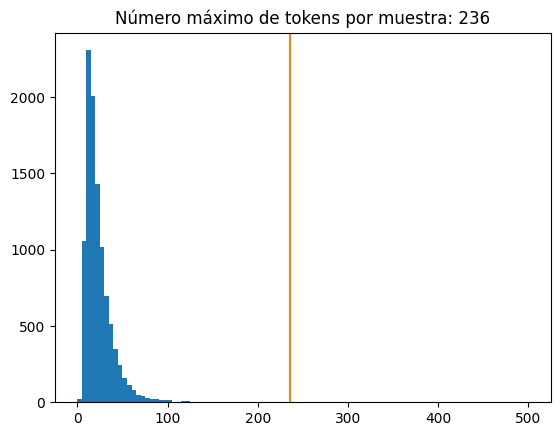

In [19]:
all_lengths = np.concatenate(lengths)

def plot_distribucion_longitudes_tokens(all_lengths):
  plt.hist(all_lengths, np.linspace(0, 500, 101))
  plt.ylim(plt.ylim())
  max_length = max(all_lengths)
  plt.plot([max_length, max_length], plt.ylim())
  plt.title(f'Número máximo de tokens por muestra: {max_length}');

plot_distribucion_longitudes_tokens(all_lengths)

#### Configuración del pipeline de datos usando `tf.data`


La siguiente función toma batches de texto como entrada y los convierte a un formato adecuado para el entrenamiento.

1.  Los tokeniza en lotes de diferentes dimensiones (ragged).
2.  Recorta cada uno para que no tenga más de `MAX_TOKENS`.
3.  Divide los tokens objetivo (inglés) en entradas y etiquetas. Estos se desplazan un paso de modo que en cada ubicación de entrada, la `etiqueta` es el ID del siguiente token.
4.  Convierte los `RaggedTensor` en `Tensor` densos con padding.
5.  Devuelve un par `(entradas, etiquetas)`.

In [20]:
MAX_TOKENS=64
def prepare_batch(pt, en):
    ### CODE HERE ###
    pt = tokenizers.pt.tokenize(pt) #obtener la representación númerica
    pt = pt[:, :MAX_TOKENS]
    pt = pt.to_tensor()

    en = tokenizers.en.tokenize(en)
    en = en[:, :(MAX_TOKENS+1)]
    en_inputs = en[:,:-1].to_tensor()
    en_labels = en[:,1:].to_tensor()
    ### --------- ###

    return (pt, en_inputs), en_labels

La siguiente función convierte un conjunto de datos de ejemplos de texto en datos de lotes para el entrenamiento.

1.  Tokeniza el texto y filtra las secuencias que son demasiado largas.
2.  Luego, `shuffle` y preparar el batch.
3.  Finalmente, `prefetch` ejecuta el conjunto de datos en paralelo con el modelo para asegurar que los datos estén disponibles cuando se necesiten. Consulta [Mejorar rendimiento con `tf.data`](https://www.tensorflow.org/guide/data_performance.ipynb) para más detalles.

In [21]:
BUFFER_SIZE = 200
BATCH_SIZE = 64

In [22]:
def make_batches(ds):
  return (
      ds
      .shuffle(BUFFER_SIZE)
      .batch(BATCH_SIZE)
      .map(prepare_batch, tf.data.AUTOTUNE)
      .prefetch(buffer_size=tf.data.AUTOTUNE))

Probar nuestro pipeline de datos

In [23]:
# Crear los conjuntos de entrenamiento y validación
train_batches = make_batches(train_examples)
test_batches = make_batches(test_examples)
val_batches = make_batches(val_examples)

Como se verían las entradas y sálidas en nuestro pipeline de datos?

<table>
<tr>
  <th>Inputs en la parte inferior, labels en la parte superior.</th>
</tr>
<tr>
  <td>
   <img width=300 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-1layer-words.png"/>
  </td>
</tr>
</table>


Esta configuración se llama "**teacher forcing**" porque, independientemente de la salida del modelo en cada paso de tiempo, recibe el valor verdadero como entrada para el siguiente paso de tiempo. Esta es una forma simple y eficiente de entrenar un modelo de generación de texto.

In [24]:
# visualizar un ejemplo de nuestros datos para entrenar
for (pt, en), en_labels in train_batches.take(1):
  print(pt.shape)
  print(en.shape)
  print(en_labels.shape)
  break

(64, 64)
(64, 64)
(64, 64)


Las etiquetas `en` y `en_labels` son las mismas, sólo que desplazadas en 1:

In [25]:
print(en[0][:10])
print(en_labels[0][:10])

tf.Tensor([   2   45  125   81  718 1091   72  640   15    0], shape=(10,), dtype=int64)
tf.Tensor([  45  125   81  718 1091   72  640   15    3    0], shape=(10,), dtype=int64)


### Definir los componentes del Transformer

Dentro de un Transformer pasan muchas cosas. Las cosas importantes que hay que recordar son:

*   Sigue el mismo patrón general que un modelo estándar secuencia-a-secuencia con un codificador y un decodificador.
*   Si trabajas paso a paso, todo tendrá sentido.

<table>
<tr>
  <th colspan=1>Diagrama original del Transformer</th>
  <th colspan=1>Representación de un Transformer de 4 capas</th>
</tr>
<tr>
  <td>
   <img width=300 src="https://www.tensorflow.org/images/tutorials/transformer/transformer.png"/>
  </td>
  <td>
   <img width=207 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-4layer-compact.png"/>
  </td>
</tr>
</table>


### La capa para la codificación de la posición

Las entradas tanto del codificador como del decodificador utilizan la misma lógica de incrustación y codificación posicional

<table>
<tr>
  <th colspan=1>The embedding and positional encoding layer</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/PositionalEmbedding.png"/>
  </td>
</tr>
</table>

Dada una secuencia de tokens, tanto los tokens de entrada (portugués) como los tokens objetivo (inglés) deben convertirse en vectores utilizando una capa `tf.keras.layers.Embedding`.

Las capas de atención utilizadas en todo el modelo ven su entrada como un conjunto de vectores, sin ningún orden. Dado que el modelo no contiene ninguna capa recurrente o convolucional, necesita alguna forma de identificar el orden de las palabras; de lo contrario, vería la secuencia de entrada como una instancia de [bolsa de palabras](https://developers.google.com/machine-learning/glossary#bag-of-words), `cómo estás tú`, `cómo tú estás`, `tú cómo estás`, y así sucesivamente, son indistinguibles.

Por lo tanto, el Transformer agrega una "Codificación Posicional" a los vectores de embedding. Utiliza un conjunto de senos y cosenos en diferentes frecuencias (a lo largo de la secuencia). Por definición, los elementos cercanos tendrán codificaciones posicionales similares.

El paper original usa la siguiente formúla para la codificación posicional:

$$\Large{PE_{(pos, 2i)} = \sin(\frac{pos}{10000^{\frac{2i}{d_{model}}}})} $$
$$\Large{PE_{(pos, 2i+1)} = \cos(\frac{pos}{10000^{\frac{2i}{d_{model}}}})} $$

Nota: El código a continuación lo implementa, pero en lugar de intercalar los senos y cosenos, los vectores de senos y cosenos simplemente se concatenan. Permutar los canales de esta manera es funcionalmente equivalente, y un poco más fácil de implementar y mostrar en las gráficas siguientes.

**Explicación Paso a Paso:**
Imaginemos que tenemos una frase: "**El gato está en la alfombra**".

Y supongamos que $d_{model}$ = 4.  Esto significa que cada posición (cada palabra) se representará con un vector de 4 números.

1. Posiciones:

* "El" está en la posición 0.
* "gato" está en la posición 1.
* "está" está en la posición 2.
* "en" está en la posición 3.
* "la" está en la posición 4.
* "alfombra" está en la posición 5.

2. Dimensiones:

Como $d_{model}$ = 4, tendremos dimensiones 0, 1, 2, y 3 en nuestro vector de codificación posicional.

3. Aplicando la Fórmula (Ejemplo: la palabra "gato" en la posición 1):

* Para la dimensión 0 (2i = 0, entonces i = 0):

```
PE(1, 0) = sin(1 / 10000^(2*0 / 4)) = sin(1 / 10000^0) = sin(1 / 1) = sin(1) ≈ 0.841
```
* Para la dimensión 1 (2i + 1 = 1, entonces i = 0):

```
PE(1, 1) = cos(1 / 10000^(2*0 / 4)) = cos(1 / 10000^0) = cos(1 / 1) = cos(1) ≈ 0.540
```

* Para la dimensión 2 (2i = 2, entonces i = 1):

```
PE(1, 2) = sin(1 / 10000^(2*1 / 4)) = sin(1 / 10000^(1/2)) = sin(1 / 100) = sin(0.01) ≈ 0.01
```

* Para la dimensión 3 (2i + 1 = 3, entonces i = 1):

```
PE(1, 3) = cos(1 / 10000^(2*1 / 4)) = cos(1 / 10000^(1/2)) = cos(1 / 100) = cos(0.01) ≈ 0.99995
```

Entonces, la codificación posicional para la palabra "gato" (posición 1) sería aproximadamente el vector: [0.841, 0.540, 0.01, 0.99995].



**¿Por qué senos y cosenos?**

Porque generan patrones periódicos suaves y únicos para cada posición, permitiendo al modelo:

Capturar relaciones relativas y absolutas.

Generalizar a secuencias más largas que las vistas en entrenamiento.

Usar la atención para comparar diferencias de posición (por la estructura trigonométrica).

In [26]:
def positional_encoding(length, depth):
  ### CODE HERE ###
  depth = depth/2
  positions = np.arange(length)[:, np.newaxis]
  depths = np.arange(depth)[np.newaxis, :]/depth

  angle_rates = 1 / (10000**depths)
  angle_rads = positions * angle_rates

  pos_encoding = np.concatenate(
      [np.sin(angle_rads), np.cos(angle_rads)],
      axis=-1)
  ### --------- ###

  return tf.cast(pos_encoding, dtype=tf.float32)

La función de codificación de posición es una pila de senos y cosenos que vibran a distintas frecuencias según su ubicación a lo largo de la profundidad del vector de incrustación. Vibran a través del eje de posición.

In [27]:
# para el ejemplo de nuestra frase: El gato esta en la alfombra
# en este caso se concatenaron las funciones
positional_encoding(length=6, depth=4)

<tf.Tensor: shape=(6, 4), dtype=float32, numpy=
array([[ 0.        ,  0.        ,  1.        ,  1.        ],
       [ 0.84147096,  0.00999983,  0.5403023 ,  0.99995   ],
       [ 0.9092974 ,  0.01999867, -0.41614684,  0.9998    ],
       [ 0.14112   ,  0.0299955 , -0.9899925 ,  0.99955004],
       [-0.7568025 ,  0.03998933, -0.6536436 ,  0.9992001 ],
       [-0.9589243 ,  0.04997917,  0.2836622 ,  0.99875027]],
      dtype=float32)>

(2048, 256)


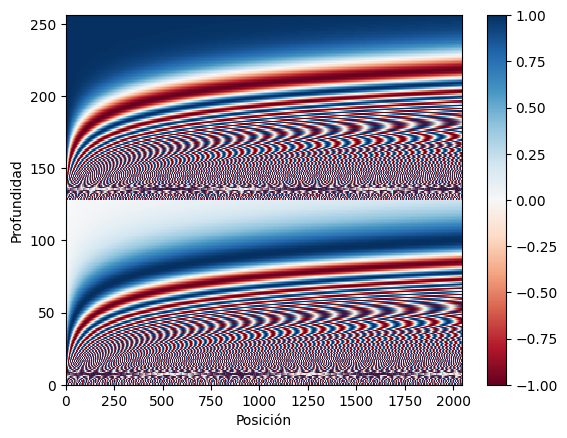

In [28]:
pos_encoding = positional_encoding(length=2048, depth=256)

# Revisar la dimensión
print(pos_encoding.shape)

plot_positional_encodings(pos_encoding)

Por definición, estos vectores se alinean bien con los vectores cercanos a lo largo del eje de posición. A continuación, los vectores de codificación de posición se normalizan y el vector de la posición `1000` se compara, por producto punto, con todos los demás:

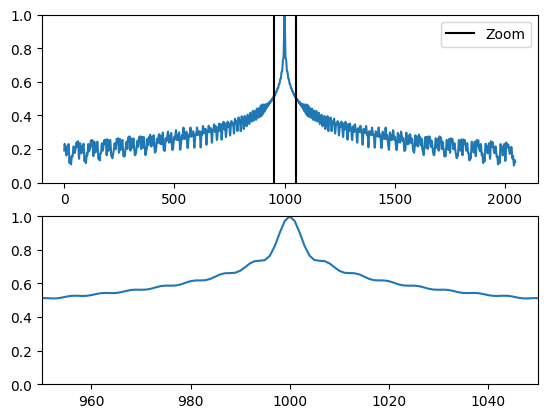

In [29]:
plot_similaridad_positional_encodings(pos_encoding)

Lo que podemos observar es que positional embedding cercanos al vector 1000 tienen cierta similitud, debido a que su producto punto son cercanos a 1:
- 1 si son identicos
- 0 ortogonales
- -1 opuestos

Ahora creemos la capa: `PositionEmbedding`

Lo que haremos es tomar la capa de embedding y aplicarle nuestra función de positional encoding

In [31]:
class PositionalEmbedding(tf.keras.layers.Layer):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.d_model = d_model
    ### CODE HERE ###
    self.embedding = tf.keras.layers.Embedding(vocab_size, d_model, mask_zero=True)
    self.pos_encoding = positional_encoding(length=2048, depth=d_model)

    ### --------- ###

  def compute_mask(self, *args, **kwargs):
    return self.embedding.compute_mask(*args, **kwargs)

  def call(self, x):
    ### CODE HERE ###
    x = self.embedding(x)
    # se multiplica el embeding por la raíz de los modelos para darle mayor relevancia
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x += self.pos_encoding[tf.newaxis, :tf.shape(x)[1], :]
    ### --------- ###
    return x

In [ ]:
embed_pt = PositionalEmbedding(vocab_size=tokenizers.pt.get_vocab_size().numpy(), d_model=512)
embed_en = PositionalEmbedding(vocab_size=tokenizers.en.get_vocab_size().numpy(), d_model=512)

pt_emb = embed_pt(pt)
en_emb = embed_en(en)

In [36]:
# la máscara de cada oración, recordar que las oraciones no tiene la misma
# longitud, asi que se aplica la máscara
en_emb._keras_mask

<tf.Tensor: shape=(64, 64), dtype=bool, numpy=
array([[ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False]])>

#### Capas de Adición y normalización

<table>
<tr>
  <th colspan=2>Add y normalize</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/Add+Norm.png"/>
  </td>
</tr>
</table>

Estos bloques de "Add & Norm" se encuentran distribuidos a lo largo de todo el modelo Transformer. Cada uno combina una conexión residual y pasa el resultado a través de una capa de `LayerNormalization`.

La manera más sencilla de organizar el código es estructurándolo alrededor de estos bloques residuales. En las siguientes secciones, definiremos clases de capas personalizadas para cada uno de ellos.

Los bloques residuales "Add & Norm" se incluyen para que el entrenamiento sea eficiente. La conexión residual proporciona una ruta directa para el gradiente (y asegura que los vectores sean **actualizados** por las capas de atención en lugar de ser **reemplazados**), mientras que la normalización mantiene una escala razonable para las salidas.

**Nota**: Las implementaciones que se muestran a continuación utilizan la capa `Add` para asegurar que las máscaras de Keras se propaguen correctamente (el operador `+` no lo hace).


#### Bases de la capa de atención

Las capas de atención se utilizan a lo largo de todo el modelo Transformer. Todas ellas son idénticas, excepto por cómo se configura la atención. Cada una contiene una capa `layers.MultiHeadAttention`, una capa `layers.LayerNormalization` y una capa `layers.Add`.


<table>
<tr>
  <th colspan=2>Capa de atención básica</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/BaseAttention.png"/>
  </td>
</tr>
</table>

Para implementar estas capas de atención, comenzaremos con una clase base simple que sólo contenga definidos los componentes. Cada caso de uso se implementará como una subclase.

In [33]:
class BaseAttention(tf.keras.layers.Layer):
  def __init__(self, **kwargs):
    super().__init__()
    ### CODE HERE ###
    self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()
    ### --------- ###

## **Atención ¿cómo funciona?**

Antes de entrar en los detalles de cada uso, aquí tienes un breve repaso de cómo funciona la atención:

<table>
<tr>
  <th colspan=1>Capa de atención básica</th>
</tr>
<tr>
  <td>
   <img width=300 src="https://www.tensorflow.org/images/tutorials/transformer/BaseAttention-new.png"/>
  </td>
</tr>
</table>

Hay dos entradas:
1. La secuencia de consulta (*query sequence*): la secuencia que se está procesando; la secuencia que "atiende" (abajo).
2. La secuencia de contexto (*context sequence*): la secuencia a la que se está "atendiendo" (izquierda).

La salida tiene la misma forma que la secuencia de consulta.

Una analogía común es que esta operación se asemeja a una búsqueda en un diccionario. Una búsqueda en un diccionario **difuso**, **diferenciable** y **vectorizado**.

Aquí tienes un diccionario regular de Python, con 3 claves y 3 valores al que se le pasa una única consulta.

```
d = {'color': 'azul', 'edad': 22, 'tipo': 'pickup'}
result = d['color']
```

- El `query` es lo que se esta tratando de encontrar.
- The `key` es el tipo de información que tiene el diccionario
- The `value` es la información

Cuando buscas una `query` (consulta) en un diccionario normal, el diccionario encuentra la `key` (clave) coincidente y devuelve su `value` (valor) asociado. La `query` tiene una `key` coincidente o no la tiene.

Puedes imaginar un diccionario **difuso** donde las claves no tienen que coincidir perfectamente. Si buscaras `d["especie"]` en el diccionario de arriba, quizás querrías que devolviera `"pickup"` ya que es la mejor coincidencia para la consulta.

Una capa de atención realiza una búsqueda difusa como esta, pero no solo busca la mejor clave. Combina los `values` basándose en qué tan bien la `query` coincide con cada `key`.

¿Cómo funciona esto? En una capa de atención, la `query`, la `key` y el `value` son cada uno vectores. En lugar de realizar una búsqueda de asignación, la capa de atención combina los vectores de la `query` y la `key` para determinar qué tan bien coinciden, obteniendo una "puntuación de atención" (*attention score*). La capa devuelve el promedio de todos los `values`, ponderado por las "puntuaciones de atención".

Cada posición en la secuencia de consulta (*query sequence*) proporciona un vector de `query`. La secuencia de contexto (*context sequence*) actúa como el diccionario. Cada posición en la secuencia de contexto proporciona un vector de `key` y un vector de `value`.

Los vectores de entrada no se utilizan directamente; la capa `layers.MultiHeadAttention` incluye capas `layers.Dense` para proyectar los vectores de entrada antes de utilizarlos.


### Capa de atención cruzada

En el centro literal del Transformer está la capa de atención cruzada. Esta capa conecta el codificador y el decodificador. Esta capa es el uso más directo de la atención en el modelo, realiza la misma tarea que el bloque de atención en el [Tutorial NMT con atención](https://www.tensorflow.org/text/tutorials/nmt_with_attention).

<table>
<tr>
  <th colspan=1>Atención cruzada</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/CrossAttention.png"/>
  </td>
</tr>
</table>

Para implementar esto, pasas la secuencia objetivo `x` como la `query` (consulta) y la secuencia de `context` (contexto) como la `key/value` (clave/valor) al llamar a la capa `mha`:


In [34]:
class CrossAttention(BaseAttention):
  def call(self, x, context):
    ### CODE HERE ###
    attn_output, attn_scores = self.mha(
        query=x,
        value=context,
        key=context,
        return_attention_scores=True)

    self.last_attn_scores = attn_scores

    x = self.add([x, attn_output])
    x = self.layernorm(x)
    ### --------- ###

    return x

La siguiente ilustración muestra cómo fluye la información a través de esta capa. Las columnas representan la suma ponderada de la secuencia contextual.

Para simplificar, no se muestran las conexiones residuales.
<table>
<tr>
  <th>Atención cruzada</th>
</tr>
<tr>
  <td>
   <img width=430 src="https://www.tensorflow.org/images/tutorials/transformer/CrossAttention-new-full.png"/>
  </td>
</tr>
</table>

La longitud de la salida es la longitud de la secuencia de `query` (consulta), y no la longitud de la secuencia de `key/value` (clave/valor) del contexto.

El diagrama se simplifica aún más a continuación. No es necesario dibujar la matriz completa de "pesos de atención".

El punto clave es que cada ubicación en la `query` puede "ver" todos los pares de `key/value` en el contexto, pero no se intercambia información entre las diferentes consultas.

<table>
<tr>
  <th>Cada elemento del query puede ver todo el contexto.</th>
</tr>
<tr>
  <td>
   <img width=430 src="https://www.tensorflow.org/images/tutorials/transformer/CrossAttention-new.png"/>
  </td>
</tr>
</table>


In [69]:
sample_ca = CrossAttention(num_heads=2, key_dim=256)

print(pt_emb.shape)
print(en_emb.shape)
# cada token de la frase en inglés
# será operados con todos los tokens de
# la oración en portugués, esto pasa así
# solo en entrenamiento
print(sample_ca(en_emb, pt_emb).shape)

(64, 64, 512)
(64, 64, 512)
(64, 64, 512)


### **Capa global de auto-atención**

Esta capa se encarga de procesar la secuencia contextual y de propagar la información a lo largo de la misma:

<table>
<tr>
  <th colspan=1>La capa global de auto-atención</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/SelfAttention.png"/>
  </td>
</tr>
</table>

Dado que la secuencia contextual es fija mientras se genera la traducción (entrenamiento), se permite que la información fluya en ambas direcciones.

Antes de los Transformers y la autoatención, los modelos solían utilizar RNNs o CNNs para realizar esta tarea (bidireccionalidad):

In [36]:
class GlobalSelfAttention(BaseAttention):
  def call(self, x):
    ### CODE HERE ###
    attn_output = self.mha(
        query=x,
        value=x,
        key=x)

    x = self.add([x, attn_output])
    x = self.layernorm(x)

    ### --------- ###
    return x

In [37]:
sample_gsa = GlobalSelfAttention(num_heads=2, key_dim=256)

print(pt_emb.shape)
print(sample_gsa(pt_emb).shape)

(64, 64, 512)
(64, 64, 512)


## **Capa de auto-atención causal**

Esta capa realiza un trabajo similar al de la capa de autoatención global, para la secuencia de salida.

La variante es que es una capa causal, solo toma los tokens anteriores o actuales para predecir la siguiente palabra. No usa palabras "futuras" o siguientes.

<table>
<tr>
  <th colspan=1>Capa causal de auto-atención</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/CausalSelfAttention.png"/>
  </td>
</tr>
</table>

Para construir una capa de auto-atención causal, necesitas usar una máscara apropiada al calcular las puntuaciones de atención y sumar los `values` de atención.

Esto se gestiona automáticamente si pasas `use_causal_mask = True` a la capa `MultiHeadAttention` cuando la llamas:

In [70]:
class CausalSelfAttention(BaseAttention):
  def call(self, x):
    ### CODE HERE ###
    attn_output = self.mha(
        query=x,
        value=x,
        key=x,
        use_causal_mask=True)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    ### --------- ###
    return x

La máscara causal garantiza que cada lugar sólo tenga acceso a los lugares que le preceden:

<table>
<tr>
  <th colspan=1>Capa de auto-atención causal.</th>
<tr>
<tr>
  <td>
   <img width=330 src="https://www.tensorflow.org/images/tutorials/transformer/CausalSelfAttention-new-full.png"/>
  </td>
</tr>
</table>

De nuevo, las conexiones residuales se omiten por simplicidad.

La representación más compacta de esta capa sería:

<table>
</tr>
  <th colspan=1>Capa de auto-atención causal.</th>
<tr>
<tr>
  <td>
   <img width=430 src="https://www.tensorflow.org/images/tutorials/transformer/CausalSelfAttention-new.png"/>
  </td>
</tr>
</table>

In [40]:
sample_csa = CausalSelfAttention(num_heads=2, key_dim=512)

print(en_emb.shape)
print(sample_csa(en_emb).shape)

(64, 64, 512)
(64, 64, 512)


In [72]:
# ejemplo donde la sálida debe ser cercana a cero
# ya que no deberia influir información posterior
out1 = sample_csa(embed_en(en[:, :3]))
out2 = sample_csa(embed_en(en))[:, :3]

tf.reduce_max(abs(out1 - out2)).numpy()

np.float32(7.1525574e-07)

## La red feed forward (FFNN)

El Transformer también incluye esta red neuronal feed-forward tanto en el codificador como en el decodificador:

<table>
<tr>
  <th colspan=1>La red feed forward (MLP)</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/FeedForward.png"/>
  </td>
</tr>
</table>

La red consiste en dos capas lineales (`tf.keras.layers.Dense`) con una función de activación ReLU entre ellas, y una capa de dropout. Al igual que con las capas de atención, el código aquí también incluye la conexión residual y la normalización:

In [42]:
class FeedForward(tf.keras.layers.Layer):
  def __init__(self, d_model, dff, dropout_rate=0.1):
    super().__init__()
    ### CODE HERE ###
    self.seq = tf.keras.Sequential([
        tf.keras.layers.Dense(dff, activation='relu'),
        tf.keras.layers.Dense(d_model),
        tf.keras.layers.Dropout(dropout_rate)
    ])

    self.add = tf.keras.layers.Add()
    self.layernorm = tf.keras.layers.LayerNormalization()

    ### --------- ###

  def call(self, x):
    ### CODE HERE ###
    x = self.add([x, self.seq(x)])
    x = self.layernorm(x)

    ### --------- ###
    return x


In [44]:
sample_ffn = FeedForward(512, 2048)

print(en_emb.shape)
print(sample_ffn(en_emb).shape)

(64, 64, 512)
(64, 64, 512)


## Capa Enconder

El codificador contiene una pila de `N` capas de codificador. Donde cada `EncoderLayer` contiene una capa `GlobalSelfAttention` y una capa `FeedForward`:

<table>
<tr>
  <th colspan=1>La capa encoder</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/EncoderLayer.png"/>
  </td>
</tr>
</table>

In [45]:
class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self,*, d_model, num_heads, dff, dropout_rate=0.1):
    super().__init__()

    ### CODE HERE ###
    self.self_attention = GlobalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.ffn = FeedForward(d_model, dff)


    ### --------- ###

  def call(self, x):
    ### CODE HERE ###
    x = self.self_attention(x)
    x = self.ffn(x)
    ### --------- ###
    return x

In [47]:
sample_encoder_layer = EncoderLayer(d_model=512, num_heads=8, dff=2048)

print(pt_emb.shape)
print(sample_encoder_layer(pt_emb).shape)

(64, 64, 512)
(64, 64, 512)


## Módulo Encoder

Construyamos el encoder, agregandole la parte de embedings y la codificación posicional.

<table>
<tr>
  <th colspan=1>El encoder</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/Encoder.png"/>
  </td>
</tr>
</table>

El codificador consiste en:

- Una capa `PositionalEmbedding` en la entrada.
- Una pila de capas `EncoderLayer`.

In [48]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads,
               dff, vocab_size, dropout_rate=0.1):
    super().__init__()

    ### CODE HERE ###
    self.d_model = d_model
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(
        vocab_size=vocab_size,
        d_model=d_model)

    self.enc_layers = []
    for _ in range(num_layers):
      self.enc_layers.append(
          EncoderLayer(d_model=d_model,
                       num_heads=num_heads,
                       dff=dff,
                       dropout_rate=dropout_rate))

    self.dropout = tf.keras.layers.Dropout(dropout_rate)

    ### --------- ###

  def call(self, x):
    ### CODE HERE ###
    x = self.pos_embedding(x)
    x = self.dropout(x)
    for i in range(self.num_layers):
      x = self.enc_layers[i](x)

    ### --------- ###

    return x  # Shape `(batch_size, seq_len, d_model)`.

In [49]:
# Instanciar el Encoder.
sample_encoder = Encoder(num_layers=4,
                         d_model=512,
                         num_heads=8,
                         dff=2048,
                         vocab_size=8000)
# Fijar training en false
sample_encoder_output = sample_encoder(pt, training=False)

# Dimensiones
print(pt.shape)
print(sample_encoder_output.shape)  # Shape `(batch_size, input_seq_len, d_model)`.
# ignorar los warnings

(64, 64)
(64, 64, 512)


## Capa Decoder

El decodificador es ligeramente más complejo, con cada `DecoderLayer` conteniendo una capa `CausalSelfAttention`, una capa `CrossAttention` y una capa `FeedForward`:

<table>
<tr>
  <th colspan=1>La capa decoder</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/DecoderLayer.png"/>
  </td>
</tr>
</table>

In [50]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self,
               *,
               d_model,
               num_heads,
               dff,
               dropout_rate=0.1):
    super(DecoderLayer, self).__init__()

    ### CODE HERE ###
    self.causal_self_attention = CausalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.cross_attention = CrossAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.ffn = FeedForward(d_model=d_model, dff=dff)

    ### --------- ###

  def call(self, x, context):
    ### CODE HERE ###
    x = self.causal_self_attention(x=x)
    x = self.cross_attention(x=x, context=context)

    self.last_attn_scores = self.cross_attention.last_attn_scores

    x = self.ffn(x)  #

    ### --------- ###
    return x

In [52]:
sample_decoder_layer = DecoderLayer(d_model=512, num_heads=8, dff=2048)

sample_decoder_layer_output = sample_decoder_layer(
    x=en_emb, context=pt_emb)

print(en_emb.shape)
print(pt_emb.shape)
print(sample_decoder_layer_output.shape)  # `(batch_size, seq_len, d_model)`

(64, 64, 512)
(64, 64, 512)
(64, 64, 512)


## Módulo Decoder

De forma similar al Codificador, el Decodificador consiste en un `PositionalEmbedding` y una pila de `DecoderLayer's`:

<table>
<tr>
  <th colspan=1>Capa Decoder + Embedding + PE</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/Decoder.png"/>
  </td>
</tr>
</table>

In [53]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads, dff, vocab_size,
               dropout_rate=0.1):
    super(Decoder, self).__init__()

    self.d_model = d_model
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size,
                                             d_model=d_model)
    self.dropout = tf.keras.layers.Dropout(dropout_rate)
    self.dec_layers = [
        DecoderLayer(d_model=d_model, num_heads=num_heads,
                     dff=dff, dropout_rate=dropout_rate)
        for _ in range(num_layers)]

    self.last_attn_scores = None

  def call(self, x, context):
    # `x` es token-IDs shape (batch, target_seq_len)
    x = self.pos_embedding(x)  # (batch_size, target_seq_len, d_model)

    x = self.dropout(x)

    for i in range(self.num_layers):
      x  = self.dec_layers[i](x, context)

    self.last_attn_scores = self.dec_layers[-1].last_attn_scores

    # EL shape de x es (batch_size, target_seq_len, d_model).
    return x

In [54]:
# Instanciar el decoder
sample_decoder = Decoder(num_layers=4,
                         d_model=512,
                         num_heads=8,
                         dff=2048,
                         vocab_size=8000)

output = sample_decoder(
    x=en,
    context=pt_emb)

# Shapes.
print(en.shape)
print(pt_emb.shape)
print(output.shape)

(64, 64)
(64, 64, 512)
(64, 64, 512)


In [56]:
sample_decoder.last_attn_scores.shape  # (batch, heads, target_seq, input_seq)

TensorShape([64, 8, 64, 64])

Una vez creados el codificador y el decodificador, es hora de construir el modelo Transformer y entrenarlo.

## El Transformer

Con el codificador y el decodificador listo. Para construír nuestro transformer, lo que necesitamos es unirlos y anadir una capa lineal al final `Dense`, que convierta el vector resultante en cada ubicación de probabilidades de los tokens.

<table>
<tr>
  <th colspan=1>El transformer</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/transformer.png"/>
  </td>
</tr>
</table>

Crea el `Transformer` extendiendo `tf.keras.Model`:

> Nota: El [artículo original](https://arxiv.org/pdf/1706.03762.pdf), sección 3.4, comparte la matriz de pesos entre la capa de embedding y la capa lineal final. Para mantener las cosas simples, este tutorial utiliza dos matrices de pesos separadas.

In [55]:
class Transformer(tf.keras.Model):
  def __init__(self, *, num_layers, d_model, num_heads, dff,
               input_vocab_size, target_vocab_size, dropout_rate=0.1):
    super().__init__()
    self.encoder = Encoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           vocab_size=input_vocab_size,
                           dropout_rate=dropout_rate)

    self.decoder = Decoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           vocab_size=target_vocab_size,
                           dropout_rate=dropout_rate)

    self.final_layer = tf.keras.layers.Dense(target_vocab_size)

  def call(self, inputs):
    # Para usar el `.fit` del modelo keras usted debe pasar
    # todas las inputs como el primer argumento
    context, x  = inputs

    context = self.encoder(context)  # (batch_size, context_len, d_model)

    x = self.decoder(x, context)  # (batch_size, target_len, d_model)

    # Capa final densa lineal
    logits = self.final_layer(x)  # (batch_size, target_len, target_vocab_size)

    try:
      # Eliminar las máscaras para que no afecten el cálculo del loss y métricas
      # b/250038731 --> relacionado con este bug que fue reportado
      del logits._keras_mask
    except AttributeError:
      pass

    # retornar la salida final
    return logits

## Hiperparámetros

Para mantener este ejemplo pequeño y relativamente rápido, el número de capas (`num_layers`), la dimensionalidad de los embeddings (`d_model`) y la dimensionalidad interna de la capa `FeedForward` (`dff`) se han reducido.

El modelo base descrito en el artículo original del Transformer utilizaba `num_layers=6`, `d_model=512` y `dff=2048`.

El número de cabezas de auto-atención será (`num_heads=4`).

In [56]:
num_layers = 2
d_model = 128
dff = 256
num_heads = 4
dropout_rate = 0.2

### Probemos el transformer

Instanciar el modelo `Transformer`:

In [57]:
int(tokenizers.pt.get_vocab_size().numpy())

7765

In [58]:
transformer = Transformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=int(tokenizers.pt.get_vocab_size().numpy()),
    target_vocab_size=int(tokenizers.en.get_vocab_size().numpy()),
    dropout_rate=dropout_rate)

In [59]:
output = transformer((pt, en))

print(en.shape)
print(pt.shape)
print(output.shape)

(64, 64)
(64, 64)
(64, 64, 7010)


In [60]:
# acceder a los scores de atención
attn_scores = transformer.decoder.dec_layers[-1].last_attn_scores
print(attn_scores.shape)  # (batch, heads, target_seq, input_seq)

(64, 4, 64, 64)


## Training

Tiempo de entrenar!!

### Configurar el optimizador

Utilizar el optimizador Adam con un planificador personalizado para la tasa de aprendizaje según la fórmula del Transformer original. [paper](https://arxiv.org/abs/1706.03762).

$$\Large{lrate = d_{model}^{-0.5} * \min(step{\_}num^{-0.5}, step{\_}num \cdot warmup{\_}steps^{-1.5})}$$

### Explicación esquema de Learning Rate del Transformer

**Parámetros:**

1.  **`d_model` (Dimensionalidad del Modelo):**
    * **Intuición:** "Ancho" del modelo. Mayor `d_model` = representaciones más ricas, más capacidad.
    * **Efecto:** Actúa como un factor de escala base para el learning rate.
      - Si d_model es grande, este factor será pequeño, lo que tiende a reducir el learning rate general. La intuición es que modelos más grandes pueden necesitar pasos de aprendizaje más pequeños para evitar inestabilidad debido a su mayor número de parámetros.
      - Si d_model es pequeño, este factor será más grande, lo que tiende a aumentar       el learning rate general.

2.  **`step_num` (Número de Paso de Entrenamiento):**
    * **Intuición:** Progreso del entrenamiento (iteración actual).
    * **Efecto:** Determina la fase del learning rate:
        * **Fase de Decaimiento (${step\\_num}^{-0.5}$):** Este término hace que el learning rate disminuya a medida que avanza el entrenamiento. La intuición es que al principio queremos dar pasos de aprendizaje más grandes para explorar el espacio de parámetros rápidamente. A medida que nos acercamos a un buen conjunto de pesos, queremos dar pasos más pequeños para "afinar" los valores y evitar oscilar alrededor del mínimo óptimo. La disminución es más pronunciada al principio y se ralentiza con el tiempo.
        * **Fase de Calentamiento (${step\\_num * warmup\\_steps}^{-1.5}$):** Este término está activo principalmente durante la fase de "calentamiento". Hace que el learning rate aumente linealmente con el número de paso hasta que step_num se acerca a warmup_steps.

3.  **`warmup_steps` (Pasos de Calentamiento):**
    * **Intuición:** Duración de la fase inicial de aumento gradual del learning rate.
    * **Efecto:** Controla cuántos pasos se tarda en alcanzar el learning rate "base". Ayuda a evitar inestabilidad al inicio.

**En resumen:**

El learning rate:

* **Aumenta gradualmente** durante los primeros `warmup_steps` para estabilizar el entrenamiento inicial.
* **Disminuye gradualmente** después de `warmup_steps` para permitir una convergencia fina.
* Su magnitud general está influenciada por la dimensionalidad del modelo (`d_model`).

In [61]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super().__init__()

    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps

  def __call__(self, step):
    step = tf.cast(step, dtype=tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

In [62]:
learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

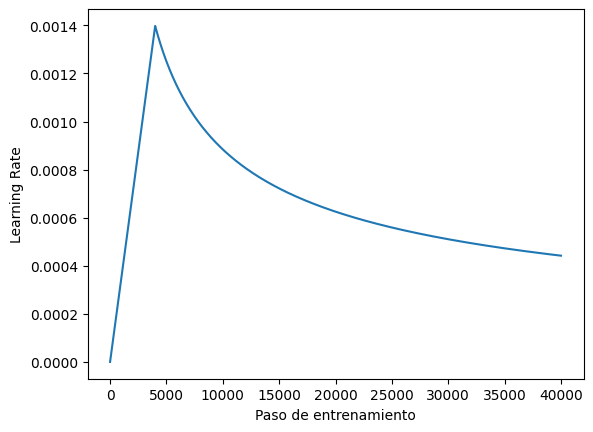

In [63]:
plot_lr_planificador(learning_rate)

### Ajustar función de pérdida y métricas

Dado que las secuencias objetivo están rellenadas (padded), es importante aplicar una máscara de padding al calcular la pérdida. Utiliza la función de pérdida de entropía cruzada (`tf.keras.losses.SparseCategoricalCrossentropy`):

In [64]:
def masked_loss(label, pred):
  mask = label != 0 # Indica padding
  # from_logits=True indica que las predicciones no han pasado por softmax.
  # reduction='none' hace que se devuelva la pérdida por cada ejemplo.
  loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
      from_logits=True, reduction='none')

  loss = loss_object(label, pred)
  mask = tf.cast(mask, dtype=loss.dtype)
  # Aplica la máscara a la pérdida, multiplicando las pérdidas de las posiciones
  # de padding por cero, lo que las elimina del cálculo total.
  loss *= mask

  # Calcula la pérdida promedio solo sobre las posiciones no enmascaradas.
  # Suma todas las pérdidas y divide por el número de posiciones no enmascaradas.
  loss = tf.reduce_sum(loss)/tf.reduce_sum(mask)
  return loss


def masked_accuracy(label, pred):
  # Obtiene la clase predicha con la probabilidad más alta (el índice máximo)
  # a lo largo del eje de vocabulario (axis=2).
  pred = tf.argmax(pred, axis=2)
  # Convierte las etiquetas al mismo tipo de dato que las predicciones para comparar.
  label = tf.cast(label, pred.dtype)
  # Crea un tensor booleano donde True indica que la predicción coincide con la etiqueta.
  match = label == pred

  # Crea una máscara donde True indica que la etiqueta no es padding (no es 0).
  mask = label != 0

  # Combina la máscara con las coincidencias. Solo consideramos como "match"
  # las predicciones correctas en las posiciones que no son padding.
  match = match & mask

  # Convierte los booleanos de 'match' y 'mask' a float para poder calcular la media.
  match = tf.cast(match, dtype=tf.float32)
  mask = tf.cast(mask, dtype=tf.float32)
  # Calcula la precisión promedio solo sobre las posiciones no enmascaradas.
  # Suma las coincidencias (1 para cada predicción correcta no enmascarada)
  # y divide por el número total de posiciones no enmascaradas.
  return tf.reduce_sum(match)/tf.reduce_sum(mask)

### Entrenar el modelo

Con todo listo, vamos a compilar usando `model.compile`, y luego entrenar con `model.fit`:

In [65]:
transformer.compile(
    loss=masked_loss,
    optimizer=optimizer,
    metrics=[masked_accuracy])

In [66]:
#history = transformer.fit(train_batches, epochs=25, validation_data=val_batches)

In [67]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=False
)

In [84]:
history = transformer.fit(train_batches,
                          epochs=20,
                          validation_data=val_batches,
                          callbacks=[early_stopping])

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 37s 460ms/step - loss: 4.6989 - masked_accuracy: 0.2744 - val_loss: 5.0714 - val_masked_accuracy: 0.2413
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 530ms/step - loss: 4.4781 - masked_accuracy: 0.3000 - val_loss: 4.9871 - val_masked_accuracy: 0.2531
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 74s 931ms/step - loss: 4.2626 - masked_accuracy: 0.3253 - val_loss: 4.9447 - val_masked_accuracy: 0.2607
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 4.0499 - masked_accuracy: 0.3508 - val_loss: 4.9235 - val_masked_accuracy: 0.2638
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - loss: 3.8440 - masked_accuracy: 0.3748 - val_loss: 4.9190 - val_masked_accuracy: 0.2664
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 328ms/step - loss: 3.6383 - masked_accuracy: 0.3988 - val_loss: 4.9336 - val_masked_accuracy: 0.2724
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 62s 653ms/step - loss: 3.4246 - masked_accuracy: 0.4242 - val_loss: 4.9443 - val_masked_accuracy: 0.2778
Epoc

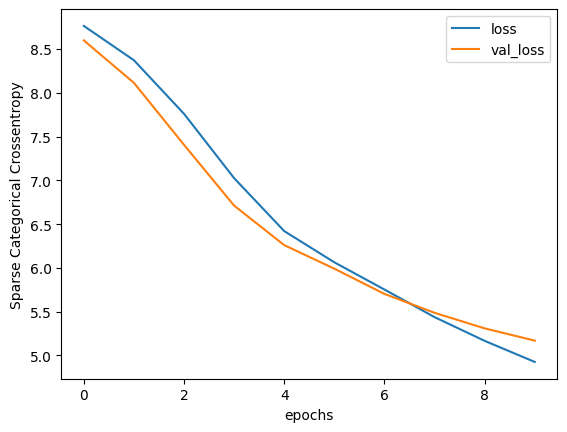

In [76]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.ylabel("Sparse Categorical Crossentropy")
plt.xlabel("epochs")
plt.legend();

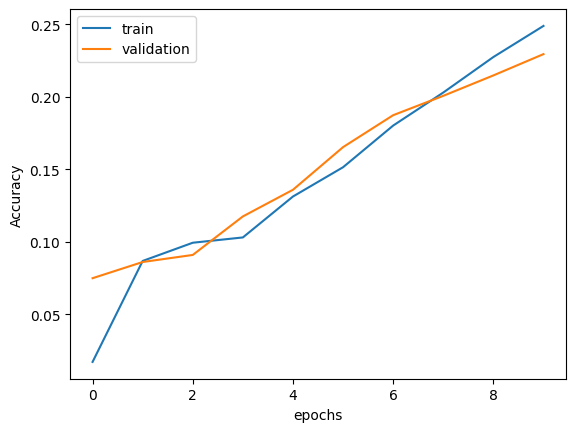

In [78]:
plt.plot(history.history['masked_accuracy'], label='train')
plt.plot(history.history['val_masked_accuracy'], label='validation')
plt.ylabel("Accuracy")
plt.xlabel("epochs")
plt.legend();

## Ejecutar inferencia

Ahora puedes probar el modelo realizando una traducción. Los siguientes pasos se utilizan para la inferencia:

* Codifica la frase de entrada utilizando el tokenizador portugués (`tokenizers.pt`). Esta es la entrada del codificador.
* La entrada del decodificador se inicializa con el token `[START]`.
* Calcula las máscaras de padding y las máscaras causales (para la auto-atención causal).
* El `decodificador` luego genera las predicciones observando la `salida del codificador` y su propia salida (auto-atención).
* Concatena el token predicho a la entrada del decodificador y lo pasa de nuevo al decodificador.
* En este enfoque, el decodificador predice el siguiente token basándose en los tokens que predijo previamente.

Nota: El modelo está optimizado para un _entrenamiento eficiente_ y realiza una predicción del siguiente token para cada token en la salida simultáneamente. Esto es redundante durante la inferencia, y solo se utiliza la última predicción. Este modelo puede hacerse más eficiente para la inferencia si solo se calcula la última predicción cuando se ejecuta en modo de inferencia (`training=False`).

Define la clase `Translator` extendiendo `tf.Module`:

In [79]:
class Translator(tf.Module):
  def __init__(self, tokenizers, transformer):
    self.tokenizers = tokenizers
    self.transformer = transformer

  def __call__(self, sentence, max_length=MAX_TOKENS):
    # La frase de entrada es portugués, por lo que se añaden los tokens `[START]` y `[END]`.
    assert isinstance(sentence, tf.Tensor)
    if len(sentence.shape) == 0:
      sentence = sentence[tf.newaxis]

    sentence = self.tokenizers.pt.tokenize(sentence).to_tensor()

    encoder_input = sentence

    # Como el lenguaje de sálida es inglés
    # Inicializar con el token `[START]`
    start_end = self.tokenizers.en.tokenize([''])[0]
    start = start_end[0][tf.newaxis]
    end = start_end[1][tf.newaxis]

    # con el TensorArray es posible hacer seguimiento al blucle dinámico
    output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
    output_array = output_array.write(0, start)

    for i in tf.range(max_length):
      # convierte la lista de tokens generados secuencialmente
      # (almacenada en el TensorArray) en un tensor con la forma (1, secuencia_de_tokens),
      # donde la secuencia de tokens representa la traducción generada hasta ese punto.
      output = tf.transpose(output_array.stack())
      predictions = self.transformer([encoder_input, output], training=False)

      # Seleccionar las predicciones para el último token de `seq_len`.
      predictions = predictions[:, -1:, :]  # Shape `(batch_size, 1, vocab_size)`.
      # Encontrar la pos del token id con la mayor probabilidad
      predicted_id = tf.argmax(predictions, axis=-1)

      # Concatenar la predicción con los anteriores tokens del decoder.
      output_array = output_array.write(i+1, predicted_id[0])

      if predicted_id == end:
        break

    output = tf.transpose(output_array.stack())
    # La dimensión de sálida es `(1, tokens)`.
    text = tokenizers.en.detokenize(output)[0]  # Shape: `()`.

    tokens = tokenizers.en.lookup(output)[0]

    # `@tf.function` optimiza la función, dificultando el acceso
    # a valores dinámicos en bucles. Recalculamos la atención
    # final fuera del bucle para obtener `attention_weights`.
    self.transformer([encoder_input, output[:,:-1]], training=False)
    attention_weights = self.transformer.decoder.last_attn_scores

    return text, tokens, attention_weights

In [80]:
translator = Translator(tokenizers, transformer)

In [81]:
sentence = 'este é um problema que temos que resolver.'
ground_truth = 'this is a problem we have to solve .'

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
print(translated_tokens)
plot_traduccion(sentence, translated_text, ground_truth)

tf.Tensor(
[b'[START]' b'it' b"'" b's' b'a' b'little' b'bit' b'of' b'the' b'world'
 b'is' b'a' b'lot' b'of' b'the' b'world' b'that' b'we' b"'" b't' b'be'
 b'a' b'lot' b'of' b'the' b'world' b'that' b'we' b"'" b't' b'have' b'a'
 b'lot' b'of' b'the' b'world' b'that' b'we' b"'" b't' b'be' b'a' b'lot'
 b'of' b'the' b'world' b'that' b'we' b"'" b't' b'have' b'a' b'lot' b'of'
 b'the' b'world' b'that' b'the' b'world' b'.' b'[END]'], shape=(61,), dtype=string)
Input:         : este é um problema que temos que resolver.
Predicción     : it ' s a little bit of the world is a lot of the world that we ' t be a lot of the world that we ' t have a lot of the world that we ' t be a lot of the world that we ' t have a lot of the world that the world .
Ground truth   : this is a problem we have to solve .


In [ ]:
sentence = 'os meus vizinhos ouviram sobre esta ideia.'
ground_truth = 'and my neighboring homes heard about this idea .'

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
plot_traduccion(sentence, translated_text, ground_truth)

Input:         : os meus vizinhos ouviram sobre esta ideia.
Predicción     : my friends had neighbors .
Ground truth   : and my neighboring homes heard about this idea .


#### Guardamos nuestro modelo

In [ ]:
transformer.export("transformer_es_pt")

## Conclusión

En este tutorial aprendiste sobre:

* Los Transformers y su importancia en el aprendizaje automático
* Atención, auto-atención y atención multi-cabeza
* Codificación posicional con embeddings
* La arquitectura codificador-decodificador del Transformer original
* Enmascaramiento en la auto-atención
* Cómo juntar todo para traducir texto

Las desventajas de esta arquitectura son:

- Para una serie temporal, la salida para un paso de tiempo se calcula a partir de la *historia completa* en lugar de solo las entradas y el estado oculto actual. Esto _podría_ ser menos eficiente.
- Si la entrada tiene una relación temporal/espacial, como texto o imágenes, debe añadirse alguna codificación posicional o el modelo efectivamente verá una bolsa de palabras.


*Este notebook se basó en el notebook de [Neural Machine Translation with a Transformer and Keras](https://colab.research.google.com/github/tensorflow/text/blob/master/docs/tutorials/transformer.ipynb) para el curso de Deep Learning práctico en 3 semanas.*

In [ ]:
!pip install transformers -y


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y


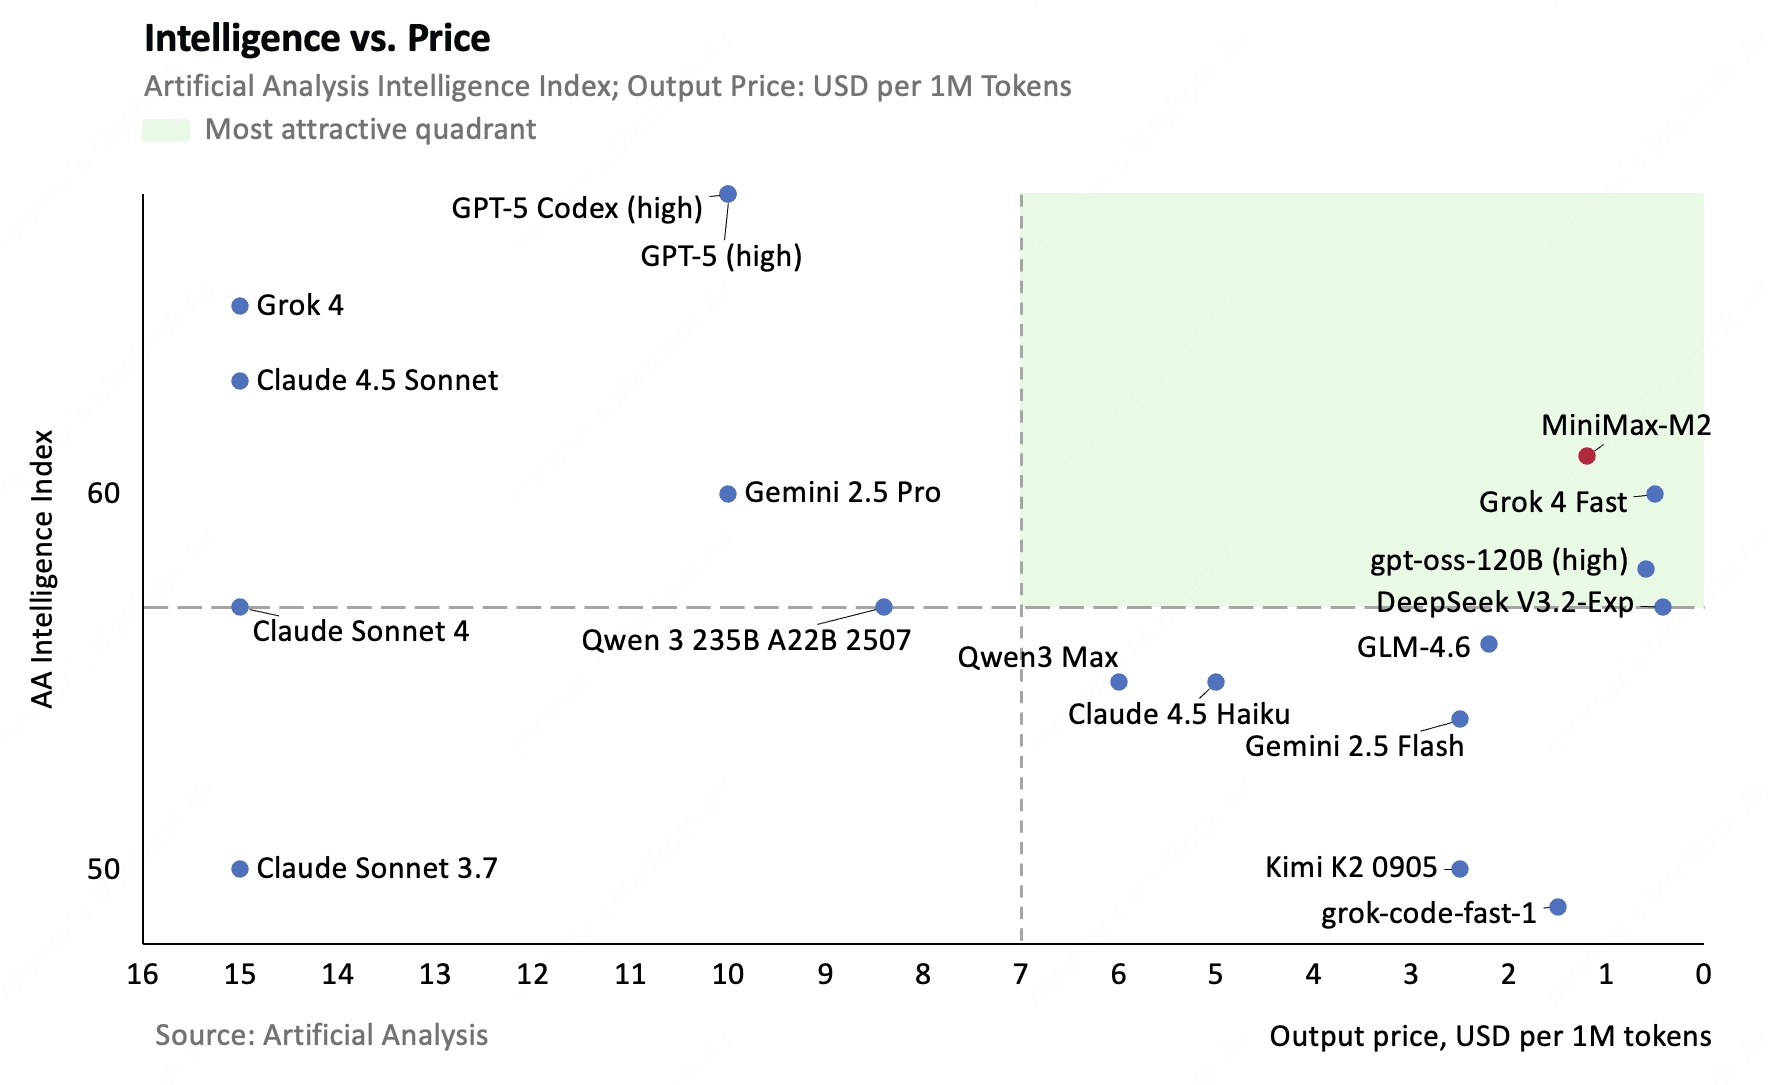

In [ ]:
!hf auth login

gpt-oss-20b — for lower latency, and local or specialized use cases (21B parameters with 3.6B active parameters)

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-generation", model="EleutherAI/gpt-neo-125m")
messages = [
    {"role": "user", "content": "Who are you?"},
]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/526M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125m
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ValueError: Cannot use chat template functions because tokenizer.chat_template is not set and no template argument was passed! For information about writing templates and setting the tokenizer.chat_template attribute, please see the documentation at https://huggingface.co/docs/transformers/main/en/chat_templating

In [ ]:
pipe("EleutherAI has", do_sample=True, min_length=20)

Passing `generation_config` together with generation-related arguments=({'do_sample', 'min_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'EleutherAI has a “strong” interest in learning the language of the Bible, and its language is, therefore, a very useful tool for its users. It is the first software to be used in a language that is intended for learning. If you are interested in learning to learn a language, you can download a free language book and learn to read it. The book will be available on Microsoft Word and Shareware.\n\nThis is a very old book, and it probably wasn’t made until a few years ago. I was curious what was going on inside and out with this book. Perhaps I should have had a different approach.\n\nThe author, Dr. John Kostin, has written on the subject of “language learning” and he has used the book to teach how to learn a language. He was curious to see how his book would work for people who have never heard of a language before.\n\nIn the book, how to learn a language is very interesting.\n\nHere is a video of the book.\n\nThe author of the book is speaking about how to learn to

In [ ]:
pipe("how were you trained?", do_sample=True, min_length=20)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'how were you trained? If so, why did you come here?"\n\n"I came to see if I could find out what you were up to."\n\n"You should be there—to see what I\'m doing."\n\n"It\'s what I was up to. You were looking for the _coup d\'état_—what were you doing when I came to see if I could find out what you were up to?"\n\n"I was looking for the _coup d\'état_. I was looking for _la place_, a place where you could get your _coup d\'état_!"\n\n"What did you think I was up to?"\n\n"The _coup d\'état_ is what you\'re looking for, after all."\n\n"What would you like for it?"\n\n"I don\'t know. I think I can work that out."\n\n"Then you\'re wrong about me."\n\n"I am not wrong about you."\n\n"But I\'m right about _me_."\n\n"But you can work out what I\'m up to, if you\'re thinking about what I\'m doing."\n\n"I wouldn\'t ask you for anything if I'}]

In [ ]:

# Use a pipeline as a high-level helper
from transformers import pipeline

pipe_llama = pipeline("text-generation", model="TinyLlama/TinyLlama-1.1B-Chat-v1.0")
messages = [
    {"role": "user", "content": "Who are you?"},
]
pipe_llama(messages)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

[{'generated_text': [{'role': 'user', 'content': 'Who are you?'},
   {'role': 'assistant',
    'content': "I'm not a human being, but I can give you some answers to your question. Here are some possible answers:\n\n1. Who are you? - This can refer to a specific human being, such as a friend, family member, coworker, or acquaintance.\n\n2. Who am I? - This expression can be used to introduce oneself to someone new, or to express one's personal identity or unique characteristics.\n\n3. Who are you looking for? - This phrase can be used to ask someone about something they're searching for, such as a job or a partner.\n\n4. Who is it? - This expression can be used to refer to someone who has been left out of a group or situation.\n\n5. Who was that? - This expression can be used to ask someone to describe someone or something they've seen, heard, or experienced.\n\n6. Who told you that? - This phrase can be used to address someone who has told you something, such as a friend or coworker.\n

In [ ]:
messages = [
    {"role": "user", "content": "y tú sabes hablar español?"},
]
pipe_llama(messages)

[{'generated_text': [{'role': 'user', 'content': 'y tú sabes hablar español?'},
   {'role': 'assistant', 'content': 'Sí, soy capaz de hablar español.'}]}]